# 03 - Pre-binning EDA: Monotonicity vs Targets

This notebook checks monotonic relationships of numeric predictors against:
1. `Opportunity Result` (Won/Loss)
2. binned deal amount target (quantile bins of `Opportunity Amount USD`)

Purpose: identify variables with stable monotonic signal before WoE/optbinning.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [3]:
df_load = pd.read_parquet('../../data/intermediate/df_train_stratified.parquet')
print('shape:', df_load.shape)
df_load.head(2)

shape: (54617, 37)


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD),total_days_zero,Opportunity Result Bool,opportunity_amount_weirdness,row_position,flag_0_days,flag_ratio_problem,flag_zero_opportunity_amount,flag_outlier_opportunity_amount,flag_outlier_total_days,flag_totally_repeated_row,flag_partially_repeated_row,partial_repeat_is_latest_id_appearance,flag_only_identified,flag_weirdness_over_75th_pct,problem_tags,problem_count,amount_qbin,stratify_key
0,7062187,Car Accessories,Towing & Hitches,Northeast,Fields Sales,41,Loss,4,41,41,200000,100K or less,1K or less,"25,000 - 50,000",NaN,0.84058,0.15942,0.0,40K to 50K,False,False,19.931465,55880,False,False,False,False,False,False,False,False,False,True,[weirdness_over_75th_pct],1,"(131000.0, 220000.0]","0__(131000.0, 220000.0]"
1,9718029,Car Accessories,Garage & Car Care,Midwest,Telesales,7,Loss,2,6,6,28763,100K or less,1K or less,0 (No business),Unknown,1.00000,0.00000,0.0,20K to 30K,False,False,4.578548,43421,False,False,False,False,False,False,False,False,True,False,[flag_only_identified],1,"(20000.0, 30000.0]","0__(20000.0, 30000.0]"


In [4]:
columns_to_use = ['Supplies Group', 'Supplies Subgroup', 'Region',
       'Route To Market', 'Elapsed Days In Sales Stage', 'Opportunity Result',
       'Sales Stage Change Count', 'Total Days Identified Through Closing',
       'Total Days Identified Through Qualified', 'Opportunity Amount USD',
       'Client Size By Revenue (USD)', 'Client Size By Employee Count',
       'Revenue From Client Past Two Years (USD)', 'Competitor Type',
       'Ratio Days Identified To Total Days',
       'Ratio Days Validated To Total Days',
       'Ratio Days Qualified To Total Days', 'Deal Size Category (USD)', "Opportunity Result Bool"]

df = df_load[columns_to_use].copy()

In [5]:
df['target_win'] = df['Opportunity Result'].map({'Won': 1, 'Loss': 0})


In [6]:
# binned amount target (ordinal classes)
df['target_amount_bin'] = pd.qcut(
    df['Opportunity Amount USD'],
    q=5,
    labels=False,
    duplicates='drop'
)

print('shape:', df.shape)
print('amount bin distribution:')
print(df['target_amount_bin'].value_counts(dropna=False).sort_index())

shape: (54617, 21)
amount bin distribution:
target_amount_bin
0    10924
1    12114
2     9738
3    10917
4    10924
Name: count, dtype: int64


## Monotonicity test function

In [7]:
def monotonicity_report(frame, x_col, y_col, n_bins=10):
    data = frame[[x_col, y_col]].dropna().copy()
    if data[x_col].nunique() < 4:
        return None

    # quantile-based bins for the predictor
    try:
        data['x_bin'] = pd.qcut(data[x_col], q=min(n_bins, data[x_col].nunique()), duplicates='drop')
    except Exception:
        return None

    agg = data.groupby('x_bin', observed=False).agg(
        x_mean=(x_col, 'mean'),
        y_mean=(y_col, 'mean'),
        n=(y_col, 'size')
    ).reset_index(drop=True)

    if len(agg) < 3:
        return None

    agg['bin_idx'] = np.arange(len(agg))
    rho, pval = spearmanr(agg['bin_idx'], agg['y_mean'])

    diffs = np.diff(agg['y_mean'].values)
    inc = np.all(diffs >= 0)
    dec = np.all(diffs <= 0)

    return {
        'variable': x_col,
        'n_bins': len(agg),
        'spearman_rho': float(rho) if pd.notna(rho) else np.nan,
        'spearman_pvalue': float(pval) if pd.notna(pval) else np.nan,
        'strict_monotonic': bool(inc or dec),
        'direction': 'increasing' if inc else ('decreasing' if dec else 'non-monotonic'),
        'curve': agg
    }

## Run monotonicity checks for both targets

In [8]:
candidate_num = [
    c for c in df.select_dtypes(include='number').columns
    if c not in {'target_win', 'target_amount_bin', 'Opportunity Amount USD', 'Opportunity Number'}
]

rows = []
curves = {}
for col in candidate_num:
    r_win = monotonicity_report(df, col, 'target_win', n_bins=10)
    r_amt = monotonicity_report(df, col, 'target_amount_bin', n_bins=10)

    if r_win is None and r_amt is None:
        continue

    rows.append({
        'variable': col,
        'win_rho': np.nan if r_win is None else r_win['spearman_rho'],
        'win_pvalue': np.nan if r_win is None else r_win['spearman_pvalue'],
        'win_strict_monotonic': False if r_win is None else r_win['strict_monotonic'],
        'win_direction': 'n/a' if r_win is None else r_win['direction'],
        'amountbin_rho': np.nan if r_amt is None else r_amt['spearman_rho'],
        'amountbin_pvalue': np.nan if r_amt is None else r_amt['spearman_pvalue'],
        'amountbin_strict_monotonic': False if r_amt is None else r_amt['strict_monotonic'],
        'amountbin_direction': 'n/a' if r_amt is None else r_amt['direction']
    })

    if r_win is not None:
        curves[(col, 'target_win')] = r_win['curve']
    if r_amt is not None:
        curves[(col, 'target_amount_bin')] = r_amt['curve']

mono_df = pd.DataFrame(rows)
mono_df['abs_win_rho'] = mono_df['win_rho'].abs()
mono_df['abs_amountbin_rho'] = mono_df['amountbin_rho'].abs()
mono_df['combined_abs_rho'] = mono_df[['abs_win_rho', 'abs_amountbin_rho']].mean(axis=1)
mono_df = mono_df.sort_values('combined_abs_rho', ascending=False).reset_index(drop=True)
mono_df

,variable,win_rho,win_pvalue,win_strict_monotonic,win_direction,amountbin_rho,amountbin_pvalue,amountbin_strict_monotonic,amountbin_direction,abs_win_rho,abs_amountbin_rho,combined_abs_rho
0,Total Days Identified Through Closing,-1.000000,0.000000,True,decreasing,0.933333,2.358998e-04,False,non-monotonic,1.000000,0.933333,0.966667
1,Total Days Identified Through Qualified,-1.000000,0.000000,True,decreasing,0.900000,9.430623e-04,False,non-monotonic,1.000000,0.900000,0.950000
2,Sales Stage Change Count,0.900000,0.037386,False,non-monotonic,1.000000,1.404265e-24,True,increasing,0.900000,1.000000,0.950000
3,Ratio Days Identified To Total Days,-1.000000,0.000000,True,decreasing,0.500000,6.666667e-01,False,non-monotonic,1.000000,0.500000,0.750000
4,Ratio Days Validated To Total Days,-1.000000,0.000000,True,decreasing,-0.400000,6.000000e-01,False,non-monotonic,1.000000,0.400000,0.700000
5,Ratio Days Qualified To Total Days,0.500000,0.666667,False,non-monotonic,-0.500000,6.666667e-01,False,non-monotonic,0.500000,0.500000,0.500000
6,Elapsed Days In Sales Stage,0.030303,0.933773,False,non-monotonic,-0.115152,7.514197e-01,False,non-monotonic,0.030303,0.115152,0.072727


In [11]:
mono_df.to_csv('../../data/bivariate_info/monotonicity_report_targets.csv', index=False)
print('saved: ../../data/bivariate_info/monotonicity_report_targets.csv')

saved: ../../data/bivariate_info/monotonicity_report_targets.csv


## Strongest monotonic variables (quick view)

In [12]:
top = mono_df.head(8)[['variable', 'win_rho', 'amountbin_rho', 'win_strict_monotonic', 'amountbin_strict_monotonic', 'combined_abs_rho']]
top

,variable,win_rho,amountbin_rho,win_strict_monotonic,amountbin_strict_monotonic,combined_abs_rho
0,Total Days Identified Through Closing,-1.000000,0.933333,True,False,0.966667
1,Total Days Identified Through Qualified,-1.000000,0.900000,True,False,0.950000
2,Sales Stage Change Count,0.900000,1.000000,False,True,0.950000
3,Ratio Days Identified To Total Days,-1.000000,0.500000,True,False,0.750000
4,Ratio Days Validated To Total Days,-1.000000,-0.400000,True,False,0.700000
5,Ratio Days Qualified To Total Days,0.500000,-0.500000,False,False,0.500000
6,Elapsed Days In Sales Stage,0.030303,-0.115152,False,False,0.072727


## Curves for top 3 variables by combined monotonic signal

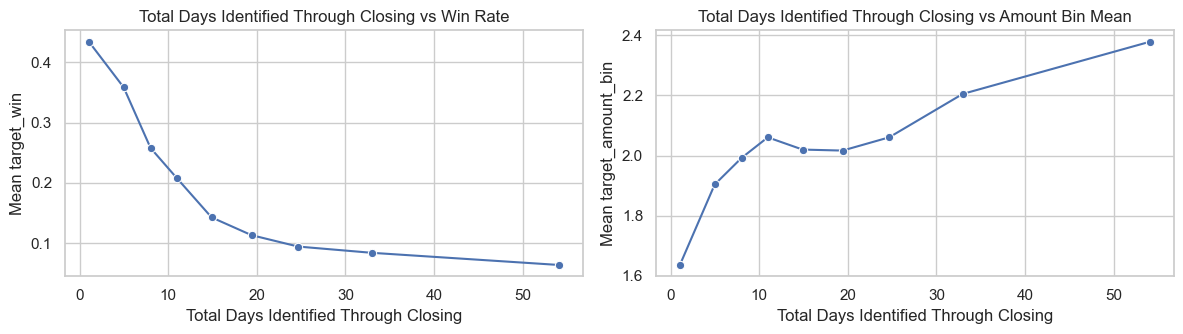

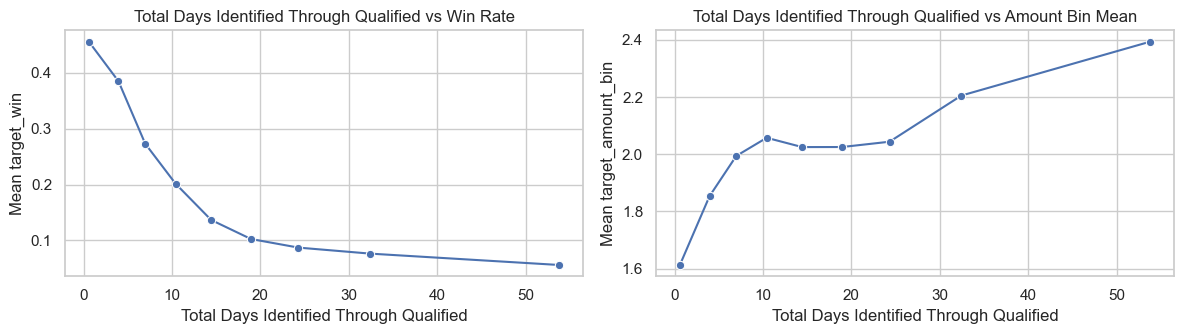

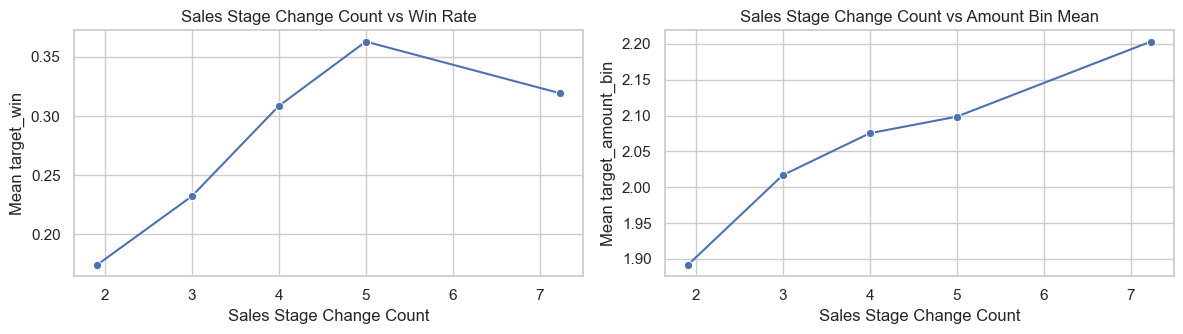

In [13]:
top_vars = mono_df.head(3)['variable'].tolist()
for var in top_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    c1 = curves.get((var, 'target_win'))
    if c1 is not None:
        sns.lineplot(data=c1, x='x_mean', y='y_mean', marker='o', ax=axes[0])
        axes[0].set_title(f'{var} vs Win Rate')
        axes[0].set_ylabel('Mean target_win')
    else:
        axes[0].set_title(f'{var} vs Win Rate (not available)')

    c2 = curves.get((var, 'target_amount_bin'))
    if c2 is not None:
        sns.lineplot(data=c2, x='x_mean', y='y_mean', marker='o', ax=axes[1])
        axes[1].set_title(f'{var} vs Amount Bin Mean')
        axes[1].set_ylabel('Mean target_amount_bin')
    else:
        axes[1].set_title(f'{var} vs Amount Bin (not available)')

    for ax in axes:
        ax.set_xlabel(var)
    plt.tight_layout()
    plt.show()

## Interpretation guide

- `spearman_rho` near `+1/-1` indicates stronger monotonic trend across bins.
- `strict_monotonic=True` means all adjacent bin means move in one direction.
- Variables with good monotonicity in both targets are strong candidates before binning models.